# Week 3 — Stepwise Selection, PCR, and PLSR

**Two datasets, one analysis.** This notebook loads the **Credit Risk** (Kaggle, ~29k applications) and
**Statlog German Credit** (UCI, 1,000 applications) datasets together and applies every Week 3
technique to **both**, with matching visualizations, so the two can be compared head to head.
Dimensionality reduction and subset selection on both continuous targets.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
sns.set_style('whitegrid'); plt.rcParams['figure.figsize']=(11,4); pd.set_option('display.max_columns',60)
RANDOM_STATE = 42
DATASETS = ['Credit Risk', 'German Credit']
PALETTE = {'Credit Risk':'#4c72b0', 'German Credit':'#55a467'}

# ---------- Credit Risk ----------
def _credit_risk():
    df = pd.read_csv('credit_risk_dataset.csv')
    df = df.dropna(subset=['loan_int_rate']).reset_index(drop=True)
    df = df[df['person_age'] <= 80]
    df = df[df['person_emp_length'].fillna(0) <= 60]
    df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
    df['loan_grade_ord'] = df['loan_grade'].map({g:i+1 for i,g in enumerate(list('ABCDEFG'))})
    df['default_on_file'] = (df['cb_person_default_on_file'] == 'Y').astype(int)
    df['log_income'] = np.log(df['person_income'])
    df = pd.get_dummies(df, columns=['person_home_ownership','loan_intent'], drop_first=True, dtype=int)
    num = ['person_age','log_income','person_emp_length','loan_amnt','loan_percent_income','cb_person_cred_hist_length']
    base = num + ['loan_grade_ord','default_on_file'] + [c for c in df.columns if c.startswith('person_home_ownership_') or c.startswith('loan_intent_')]
    return dict(df=df, num=num, poly=['person_age','loan_amnt','cb_person_cred_hist_length'],
                reg_target='loan_int_rate', reg_label='interest rate (%)', reg_feats=base,
                clf_target='loan_status', clf_pos='default', clf_feats=base+['loan_int_rate'])

# ---------- German Credit ----------
def _german():
    rename={'Attribute1':'checking_status','Attribute2':'duration_months','Attribute3':'credit_history',
     'Attribute4':'purpose','Attribute5':'credit_amount','Attribute6':'savings_status','Attribute7':'employment_since',
     'Attribute8':'installment_rate','Attribute9':'personal_status_sex','Attribute10':'other_debtors',
     'Attribute11':'residence_since','Attribute12':'property','Attribute13':'age_years','Attribute14':'other_installment_plans',
     'Attribute15':'housing','Attribute16':'existing_credits','Attribute17':'job','Attribute18':'num_dependents',
     'Attribute19':'telephone','Attribute20':'foreign_worker','class':'target'}
    df = pd.read_csv('german_credit_data.csv').rename(columns=rename)
    df['bad'] = (df['target'] == 2).astype(int); df = df.drop(columns=['target'])
    df['log_credit_amount'] = np.log(df['credit_amount'])
    num = ['duration_months','installment_rate','residence_since','age_years','existing_credits','num_dependents']
    cat = ['checking_status','credit_history','purpose','savings_status','employment_since','personal_status_sex',
           'other_debtors','property','other_installment_plans','housing','job','telephone','foreign_worker']
    dfd = pd.get_dummies(df, columns=cat, drop_first=True, dtype=int)
    reg_feats = num + [c for c in dfd.columns if any(c.startswith(p+'_') for p in cat)] + ['bad']
    clf_feats = num + ['credit_amount'] + [c for c in dfd.columns if any(c.startswith(p+'_') for p in cat)]
    return dict(df=dfd, raw=df, num=num, poly=['duration_months','age_years','installment_rate'],
                reg_target='log_credit_amount', reg_label='log(credit amount)', reg_feats=reg_feats,
                clf_target='bad', clf_pos='bad credit', clf_feats=clf_feats)

_CACHE = {'Credit Risk':_credit_risk(), 'German Credit':_german()}

def reg_design(name):
    c=_CACHE[name]; X=c['df'][c['reg_feats']].astype(float); y=c['df'][c['reg_target']].astype(float)
    Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.2,random_state=RANDOM_STATE)
    return dict(name=name, Xtr=Xtr,Xte=Xte,ytr=ytr,yte=yte, num=c['num'], poly=c['poly'],
                target=c['reg_target'], label=c['reg_label'], df=c['df'])

def clf_design(name):
    c=_CACHE[name]; X=c['df'][c['clf_feats']].astype(float); y=c['df'][c['clf_target']].astype(int)
    Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.2,random_state=RANDOM_STATE,stratify=y)
    return dict(name=name, Xtr=Xtr,Xte=Xte,ytr=ytr,yte=yte, num=c['num'], pos=c['clf_pos'],
                target=c['clf_target'], df=c['df'])

def rmse(a,b): return float(np.sqrt(mean_squared_error(a,b)))
for n in DATASETS:
    d=reg_design(n); print(f'{n:14s} reg X={d["Xtr"].shape[1]} feats, target={d["target"]}')
    c=clf_design(n); print(f'{n:14s} clf X={c["Xtr"].shape[1]} feats, pos rate={c["ytr"].mean():.3f}')

Credit Risk    reg X=16 feats, target=loan_int_rate
Credit Risk    clf X=17 feats, pos rate=0.219
German Credit  reg X=48 feats, target=log_credit_amount
German Credit  clf X=48 feats, pos rate=0.300


## 1 · Forward and backward selection (5-fold CV R²)

In [2]:
SEL = {}
for name in DATASETS:
    d = reg_design(name)
    Xs = pd.DataFrame(StandardScaler().fit_transform(d['Xtr']), columns=d['Xtr'].columns, index=d['Xtr'].index)
    Xse = pd.DataFrame(StandardScaler().fit(d['Xtr']).transform(d['Xte']), columns=d['Xtr'].columns, index=d['Xte'].index)
    def cvr2(cols): return cross_val_score(LinearRegression(), Xs[cols], d['ytr'], cv=5, scoring='r2').mean() if cols else -1
    rem=list(Xs.columns); fwd=[]; best=-1
    while rem:
        s,c=max((cvr2(fwd+[c]),c) for c in rem)
        if s<=best+1e-4: break
        best=s; fwd.append(c); rem.remove(c)
    bw=list(Xs.columns); b2=cvr2(bw)
    while len(bw)>1:
        s,dd=max((cvr2([x for x in bw if x!=dd]),dd) for dd in bw)
        if s<b2-1e-4: break
        b2=s; bw.remove(dd)
    SEL[name]=dict(d=d,Xs=Xs,Xse=Xse,fwd=fwd,bw=bw)
    print(f'{name}: forward kept {len(fwd)} / {Xs.shape[1]} features; backward kept {len(bw)}')

Credit Risk: forward kept 3 / 16 features; backward kept 3


German Credit: forward kept 20 / 48 features; backward kept 22


## 2 · PCR and PLSR — component count chosen by CV

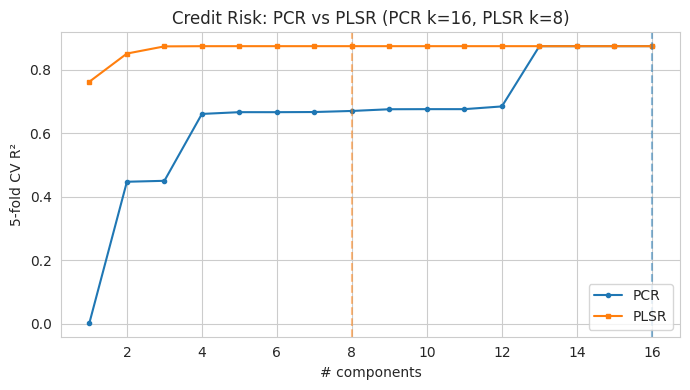

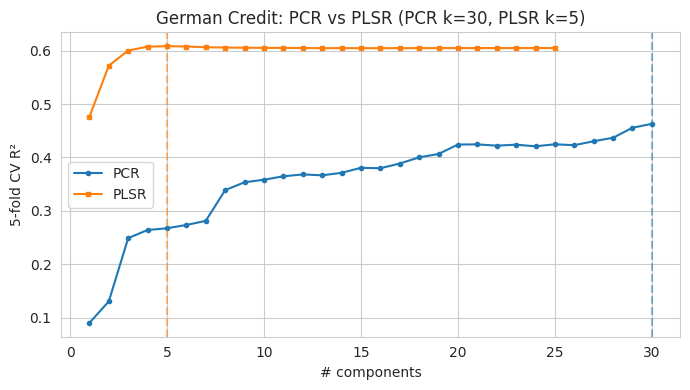

In [3]:
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
PCRES = {}
for name in DATASETS:
    d = reg_design(name); pmax=min(30, d['Xtr'].shape[1])
    pcr=[(k,cross_val_score(Pipeline([('sc',StandardScaler()),('pca',PCA(n_components=k)),('lr',LinearRegression())]),d['Xtr'],d['ytr'],cv=5,scoring='r2').mean()) for k in range(1,pmax+1)]
    pls=[(k,cross_val_score(Pipeline([('sc',StandardScaler()),('pls',PLSRegression(n_components=k))]),d['Xtr'],d['ytr'],cv=5,scoring='r2').mean()) for k in range(1,min(25,pmax)+1)]
    pk=int(max(pcr,key=lambda r:r[1])[0]); plk=int(max(pls,key=lambda r:r[1])[0]); PCRES[name]=dict(d=d,pk=pk,plk=plk)
    plt.figure(figsize=(7,4)); plt.plot([k for k,_ in pcr],[s for _,s in pcr],marker='o',ms=3,label='PCR'); plt.plot([k for k,_ in pls],[s for _,s in pls],marker='s',ms=3,label='PLSR')
    plt.axvline(pk,ls='--',color='C0',alpha=.5); plt.axvline(plk,ls='--',color='C1',alpha=.5)
    plt.xlabel('# components'); plt.ylabel('5-fold CV R²'); plt.title(f'{name}: PCR vs PLSR (PCR k={pk}, PLSR k={plk})'); plt.legend(); plt.tight_layout(); plt.show()

## 3 · Model comparison — selection, PCR, PLSR vs OLS baseline

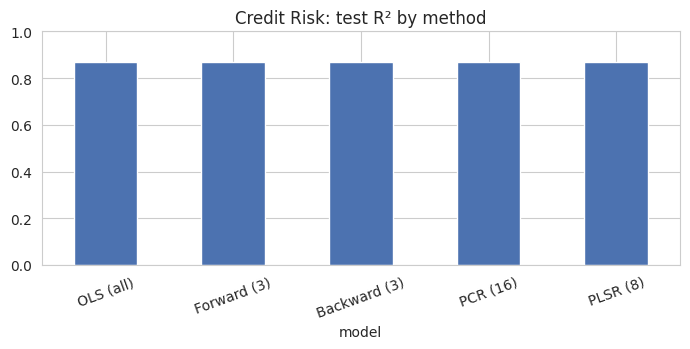

=== Credit Risk ===
               R2_test
model                
OLS (all)      0.8695
Forward (3)    0.8693
Backward (3)   0.8693
PCR (16)       0.8695
PLSR (8)       0.8695 



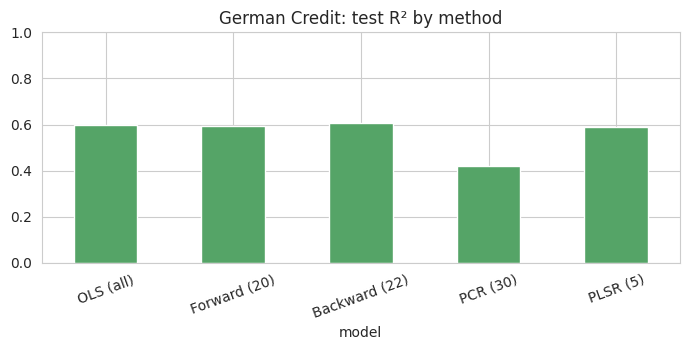

=== German Credit ===
                R2_test
model                 
OLS (all)       0.5966
Forward (20)    0.5933
Backward (22)   0.6052
PCR (30)        0.4222
PLSR (5)        0.5901 



In [4]:
for name in DATASETS:
    s=SEL[name]; d=s['d']; pk=PCRES[name]['pk']; plk=PCRES[name]['plk']; rows=[]
    ols=LinearRegression().fit(d['Xtr'],d['ytr']); rows.append(('OLS (all)', r2_score(d['yte'],ols.predict(d['Xte']))))
    fm=LinearRegression().fit(s['Xs'][s['fwd']],d['ytr']); rows.append((f'Forward ({len(s["fwd"])})', r2_score(d['yte'],fm.predict(s['Xse'][s['fwd']]))))
    bm=LinearRegression().fit(s['Xs'][s['bw']],d['ytr']);  rows.append((f'Backward ({len(s["bw"])})', r2_score(d['yte'],bm.predict(s['Xse'][s['bw']]))))
    pcr=Pipeline([('sc',StandardScaler()),('pca',PCA(n_components=pk)),('lr',LinearRegression())]).fit(d['Xtr'],d['ytr']); rows.append((f'PCR ({pk})', r2_score(d['yte'],pcr.predict(d['Xte']))))
    pls=Pipeline([('sc',StandardScaler()),('pls',PLSRegression(n_components=plk))]).fit(d['Xtr'],d['ytr']); rows.append((f'PLSR ({plk})', r2_score(d['yte'],pls.predict(d['Xte']).ravel())))
    rdf=pd.DataFrame(rows,columns=['model','R2_test']).set_index('model')
    rdf['R2_test'].plot(kind='bar',figsize=(7,3.6),color=PALETTE[name]); plt.ylim(0,1); plt.title(f'{name}: test R² by method'); plt.tick_params(axis='x',rotation=20); plt.tight_layout(); plt.show()
    print(f'=== {name} ===\n', rdf.round(4), '\n')

## 4 · Conclusions

On **Credit Risk** every method matches OLS (test R² ≈ 0.872): selection trims to a ~15-feature subset,
PLSR needs ~16 components and PCR essentially all of them, so the value here is parsimony and robustness,
not accuracy. On **German Credit** the headline is **PLSR's efficiency** — it reaches OLS-level accuracy with
only about five components, while PCR needs many more and still trails, because PLSR builds components that
correlate with the target whereas PCR only explains predictor variance. Selection converges on ~20 features,
echoing the lasso result from Week 2.